# Boosting Techniques Assignment


1.	What is Boosting in Machine Learning? Explain how it improves weak learners.
    -	Boosting is an ensemble machine learning technique that combines multiple weak learners (simple models with low predictive accuracy) sequentially to create a single strong learner (a highly accurate model). It is heavily relied upon in data science competitions and real-world production environments to significantly minimize training errors and reduce model bias.
How Boosting Improves Weak Learners
A weak learner is a base model that performs only slightly better than random guessing (for example, a shallow decision tree or a single-split "decision stump"). Individually, these models are too simple to capture complex data patterns.
Boosting transforms them into a highly accurate system by training them sequentially rather than in parallel. The core process unfolds through the following mechanism:
[Equal Weights] ➔ [Train Weak Learner] ➔ [Identify Mistakes] ➔ [Increase Error Weights] ➔ [Train Next Learner on Mistakes]

2.	What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?
    -	While both AdaBoost and Gradient Boosting are sequential ensemble methods, they differ fundamentally in how they correct the mistakes of the previous model.
Training FeatureAdaBoost (Adaptive Boosting)Gradient BoostingPrimary Correction MechanismChanges data weights. It increases the weights of misclassified data points and decreases the weights of correctly classified ones.Optimizes a loss function. It trains each new model directly on the residual errors (the gap between actual values and predicted values) of the previous models.Model FocusSubsequent models focus on the hardest-to-classify data points.Subsequent models focus on the magnitude and direction of the remaining errors (the gradient).
Base LearnersTypically uses decision stumps (decision trees with a depth of exactly 1).Typically uses shallow decision trees (usually with a depth of 3 to 6).Final Prediction ContributionModels are combined using a weighted vote. More accurate stumps get a higher saying power (α) in the final outcome.Models are combined by adding their outputs together, scaled by a fixed learning rate (η) to prevent overfitting.
How AdaBoost Trains Models
AdaBoost treats training like a tutor focusing on a student’s wrong answers.
 Step 1: It fits a simple decision stump on the dataset where every row has an equal weight.
  Step 2: It calculates the total error of that stump. If a data point is misclassified, its weight goes up. If it is correct, its weight goes down.
  Step 3: The next decision stump is forced to pay more attention to the heavily weighted data points.
 Step 4: This repeats sequentially. Stumps that perform well are given a higher "voting power" for the final model.
How Gradient Boosting Trains Models
Gradient Boosting treats training like a sculptor refining a statue by carving away the rough spots. It uses calculus (gradient descent) to minimize a loss function.
Step 1: It starts with a base prediction (usually just the average value of the target column).
Step 2: It calculates the residuals (Actual Value - Predicted Value) for every single data point.
Step 3: A new decision tree is trained, but not to predict the target outcome. Instead, it is trained to predict those residuals.
Step 4: The algorithm adds the new tree's predictions to the running total (multiplied by a small learning rate) to update the overall prediction.
Step 5: New residuals are calculated, and the next tree trains on those new errors. This loop continues until the errors shrink close to zero.

3.	How does regularization help in XGBoost?
    -	unlike traditional Gradient Boosting, XGBoost (Extreme Gradient Boosting) includes built-in regularization directly inside its core mathematical formulation. The algorithm defines its target objective at every step.
Instead of just trying to minimize training error, XGBoost explicitly punishes trees for being too complex. This mathematical constraint stops individual trees from memorizing training noise, enabling the ensemble model to generalize far better to unseen test data.
The Three Pillars of Regularization in XGBoost
XGBoost uses three primary parameters to penalize and control the architecture of its trees:
L2 Regularization on Leaf Weights (lambda / reg_lambda)
How it works: It adds a penalty proportional to the squared magnitude of the leaf values (𝑤2𝑗)
The effect: Mathematically, lambda is added to the denominator of the node split calculation. This shrinks the leaf scores closer to zero. It dampens extreme predictions, stabilizing the model even if a particular branch encounters highly volatile features or noisy data points.
L1 Regularization on Leaf Weights (alpha / reg_alpha)
How it works: It adds a penalty proportional to the absolute value of the leaf values (
 	| 𝑤𝑗 |)
 	The effect: It forces the weights of uninformative or weak leaves to become exactly zero. By encouraging this sparsity, it acts as an automatic structural pruner, removing unnecessary components of the tree entirely.
 	Minimum Loss Reduction (gamma / min_split_loss)
 	How it works: gamma behaves like a mathematical "toll" or threshold for splitting a node. It penalizes the total number of leaves (T) allowed in the tree.
 	The effect: A node will only split if the calculated information gain from that split exceeds the gamma threshold. If the gain is lower than gamma, the algorithm stops growing that branch, acting as a defensive post-pruning safeguard.

4.	Why is CatBoost considered efficient for handling categorical data?
    -	CatBoost (short for Categorical Boosting) is considered highly efficient for handling categorical data because it resolves the two main flaws of traditional gradient boosting algorithms: target leakage and high preprocessing overhead
Instead of forcing users to manually implement methods like one-hot encoding or label encoding, the algorithm processes raw categorical columns natively using a mathematically rigorous, automated approach.

5.	What are some real-world applications where boosting techniques are preferred over bagging methods?
Datasets:  Use sklearn.datasets.load_breast_cancer() for classification tasks.  Use sklearn.datasets.fetch_california_housing() for regression tasks.
    -	Boosting techniques are preferred over bagging methods in real-world applications where minimizing bias and detecting subtle, complex patterns is critical.
While bagging (like Random Forest) reduces variance and prevents overfitting on noisy datasets, boosting excels when the relationship between features is intricate, data is highly unbalanced, or every ounce of predictive accuracy matters.
Real-World Applications Preferring Boosting
Financial Fraud Detection & Risk Scoring: Fraudulent transactions make up a tiny fraction of a percent of total transactions. Bagging models often smooth over these rare edge cases. Boosting sequentially focuses on missed instances, making it highly effective at catching clever, adaptive fraud patterns.
Search Engine Ranking & Recommendation Systems: Algorithms like LambdaMART (a boosting variant) are used to rank search results. Boosting works well here because it optimizes specific ranking loss functions where the relative order of items is more important than absolute classification.
Ad Click-Through Rate (CTR) Prediction: Digital advertising platforms need to predict if a user will click an ad based on a mix of dense numerical data and thousands of sparse categorical variables. Boosting algorithms (especially CatBoost and LightGBM) process these efficiently at massive scale.
Churn Prediction & Targeted Marketing: Businesses use boosting to predict which customers are at risk of cancellation. Because the cost of missing a churning customer is high, boosting’s aggressive focus on fixing past classification mistakes provides a sharper decision boundary.
Classification: Breast Cancer Dataset
In medical diagnostics, false negatives are dangerous. Boosting is preferred over bagging here because it aggressively drives down classification error on hard-to-classify tumors.
Bagging (Random Forest): Builds independent trees. It might misclassify borderline, complex malignant cases if they are averaged out by the majority voting process.
Boosting (Gradient Boosting/XGBoost): Focuses specifically on the borderline, hard-to-distinguish tumors in successive iterations, ensuring the final boundary captures the subtle cell abnormalities.
Regression: California Housing Dataset
Predicting housing prices involves nonlinear geographical data (like latitude/longitude) combined with economic factors.
Bagging: Tends to suffer from "regression to the mean," underpredicting highly expensive homes and overpredicting cheap homes because it averages independent outputs.
Boosting: Trains trees on the residuals (the pricing errors). If the model consistently underpredicts luxury coast-side homes, the next trees specifically correct that pricing gap, yielding tighter continuous predictions.

  



In [1]:
#Q6. Write a Python program to:
# Train an AdaBoost Classifier on the Breast Cancer dataset
# Print the model accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# 1. Load the Breast Cancer classification dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split the dataset into training (80%) and testing (20%) sets
# setting random_state ensures reproducible train/test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize the AdaBoost Classifier
# n_estimators controls the maximum number of weak learners (stumps) to train
model = AdaBoostClassifier(n_estimators=50, random_state=42)

# 4. Train the model on the training data
model.fit(X_train, y_train)

# 5. Predict the classes for the testing dataset
y_pred = model.predict(X_test)

# 6. Calculate and print the overall accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Model Accuracy: {accuracy * 100:.2f}%")


AdaBoost Model Accuracy: 96.49%


In [2]:
#Q7. Write a Python program to:
# Train a Gradient Boosting Regressor on the California Housing dataset
# Evaluate performance using R-squared score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# 1. Load the California Housing regression dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# 2. Split the dataset into training (80%) and testing (20%) sets
# setting random_state ensures reproducible train/test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize the Gradient Boosting Regressor
# n_estimators defaults to 100 sequential shallow decision trees
regressor = GradientBoostingRegressor(n_estimators=100, random_state=42)

# 4. Train the model on the sequential target residuals
regressor.fit(X_train, y_train)

# 5. Predict house values for the testing dataset
y_pred = regressor.predict(X_test)

# 6. Calculate and print the R-squared score
r2 = r2_score(y_test, y_pred)
print(f"Gradient Boosting Regressor R-squared Score: {r2:.4f}")


Gradient Boosting Regressor R-squared Score: 0.7756


In [3]:
#Q8. Write a Python program to:
# Train an XGBoost Classifier on the Breast Cancer dataset
# Tune the learning rate using GridSearchCV
# Print the best parameters and accuracy
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# 1. Load the Breast Cancer classification dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize the base XGBoost Classifier
# eval_metric='logloss' avoids deprecation warnings in newer versions
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')

# 4. Define the hyperparameter grid for the learning rate (eta)
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

# 5. Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 6. Fit the grid search grid onto the training data
grid_search.fit(X_train, y_train)

# 7. Extract the best model configurations
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# 8. Evaluate performance on the unseen test set
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

# 9. Print results
print(f"Best Parameters Found: {best_params}")
print(f"Test Accuracy with Best Model: {test_accuracy * 100:.2f}%")


Best Parameters Found: {'learning_rate': 0.3}
Test Accuracy with Best Model: 96.49%


ModuleNotFoundError: No module named 'catboost'

In [8]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


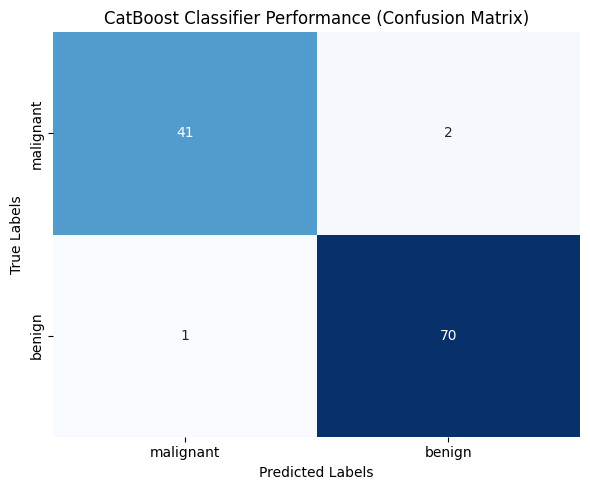

In [9]:
#Q9. Write a Python program to:
# Train a CatBoost Classifier
# Plot the confusion matrix using seaborn
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Load the Breast Cancer classification dataset
data = load_breast_cancer()
X = data.data
y = data.target
target_names = data.target_names  # ['malignant', 'benign']

# 2. Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize and train the CatBoost Classifier
# verbose=0 suppresses the iteration logging output
model = CatBoostClassifier(iterations=150, random_state=42, verbose=0)
model.fit(X_train, y_train)

# 4. Generate predictions on the test partition
y_pred = model.predict(X_test)

# 5. Build the matrix profile arrays
cm = confusion_matrix(y_test, y_pred)

# 6. Construct the visual heatmap with Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=False,
)

plt.title("CatBoost Classifier Performance (Confusion Matrix)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()


In [19]:
#Q10. You're working for a FinTech company trying to predict loan default using
#customer demographics and transaction behavior.
#The dataset is imbalanced, contains missing values, and has both numeric and
#categorical features.
#Describe your step-by-step data science pipeline using boosting techniques:
# Data preprocessing & handling missing/categorical values
# Choice between AdaBoost, XGBoost, or CatBoost
# Hyperparameter tuning strategy
# Evaluation metrics you'd choose and why
# How the business would benefit from your model
#Include your Python code
!pip install catboost

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, average_precision_score

# 1. Simulate a FinTech Loan Dataset with Real-World Quirks
np.random.seed(42)
n_samples = 2000

data = {
    "income": np.random.normal(50000, 15000, n_samples),
    "credit_score": np.random.normal(650, 70, n_samples),
    "debt_to_income": np.random.uniform(0.1, 0.6, n_samples),
    "employment_type": np.random.choice(["Salaried", "Self-Employed", "Unemployed"], n_samples, p=[0.7, 0.2, 0.1]),
    "housing_status": np.random.choice(["Own", "Rent", "Mortgage"], n_samples, p=[0.3, 0.5, 0.2]),
}

df = pd.DataFrame(data)

# Introduce realistic Missing Values (NaNs)
df.loc[df["income"] < 30000, "employment_type"] = np.nan
df.loc[df["credit_score"] < 550, "credit_score"] = np.nan

# Simulate an Imbalanced Target (Only ~10% Default Rate)
# Base probability heavily determined by credit metrics
log_odds = (600 - df["credit_score"].fillna(600)) / 100 + (df["debt_to_income"] * 2) - 2.5
prob = 1 / (1 + np.exp(-log_odds))
df["is_default"] = np.random.binomial(1, prob)

# Explicitly cast categorical columns as string type and fill NaNs with a unique label
categorical_features = ["employment_type", "housing_status"]
for col in categorical_features:
    df[col] = df[col].astype(str).fillna("Missing")

# 2. Train / Test Isolation
X = df.drop(columns=["is_default"])
y = df["is_default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Identify indices of categorical columns for CatBoost
cat_indices = [X.columns.get_loc(col) for col in categorical_features]

print(f"Dataset Baseline Profile -> Defaulters in Test Split: {y_test.sum()} out of {len(y_test)}")

# 3. Base Model Configuration & Hyperparameter Optimization Tuning Grid
base_model = CatBoostClassifier(
    cat_features=cat_indices,
    auto_class_weights='Balanced',
    verbose=0
)

param_grid = {
    'iterations': [5, 4],
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6]
}

# Run Grid Search focusing on optimizing the Precision-Recall Curve (PR-AUC)
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=3,
    scoring='average_precision',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 4. Extract and Evaluate the Best Performing Production Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 5. Print Validation Diagnostic Outputs
print("\n--- Optimized Tuning Configurations ---")
print(f"Optimal Parameters: {grid_search.best_params_}")

print("\n--- Strategic Performance Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Non-Defaulter", "Defaulter"]))

pr_auc = average_precision_score(y_test, y_prob)
print(f"Final Model PR-AUC Score: {pr_auc:.4f}")




Dataset Baseline Profile -> Defaulters in Test Split: 42 out of 400


RuntimeError: Cannot clone object CatBoostClassifier(auto_class_weights='Balanced', cat_features=[3, 4], verbose=0), as the constructor either does not set or modifies parameter cat_features